# 10. Classification — GRU (Gated Recurrent Unit)

**Scratch**: Full GRU cell (3 gates) + Adam optimiser, pure NumPy  
**PyTorch**: `nn.GRU → nn.Linear`, same hyperparameters

### Theory

A GRU simplifies the LSTM by **merging the forget and input gates** into a single *update gate* and **removing the separate cell state** — the hidden state $h_t$ carries everything. This reduces parameters by ~25% and often trains faster, especially on shorter sequences.

**Three gates** (all share input $[h_{t-1},\, x_t]$):

$$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z) \qquad \text{update gate — how much of } h_{t-1} \text{ to keep}$$
$$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r) \qquad \text{reset gate — how much of } h_{t-1} \text{ to expose to candidate}$$
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1},\, x_t] + b_h) \qquad \text{candidate hidden state}$$

**State update** (no separate cell state):
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

**GRU vs LSTM:**

| | LSTM | GRU |
|---|---|---|
| Gates | 4 (f, i, g, o) | 3 (z, r, h̃) |
| States | $h_t$ + $c_t$ | $h_t$ only |
| Parameters | $4(H^2 + DH + H)$ | $3(H^2 + DH + H)$ |
| Vanishing gradient | Mitigated via $c_t$ | Mitigated via $z_t$ |

The update gate $z_t$ plays the combined role of LSTM's forget + input gates: when $z_t \approx 0$ the GRU copies $h_{t-1}$ unchanged (like LSTM with $f_t=1, i_t=0$); when $z_t \approx 1$ it fully overwrites with $\tilde{h}_t$.

In [17]:
import os, json, pickle, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')
FEATURES_JSON = os.path.join(DATA_DIR, 'selected_features_classification.json')

# ── Shared Utilities ───────────────────────────────────────────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    """Return a dict of all evaluation metrics matching the project results CSV."""
    cm = confusion_matrix(y_true, y_pred)
    # Handle case where a class is entirely absent in predictions
    tn, fp, fn, tp = (cm.ravel() if cm.size == 4
                      else (0, 0, int((y_true == 0).sum()), int((y_true == 1).sum())))

    sensitivity  = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # = recall
    specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # = TNR

    metrics = {
        'model':       model_name,
        'accuracy':    accuracy_score(y_true, y_pred),
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tnr':         specificity,
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':     roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        'tp':          float(tp),
        'tn':          float(tn),
        'fp':          float(fp),
        'fn':          float(fn),
        'recall':      sensitivity,
    }
    return metrics

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        df = pd.read_csv(RESULTS_CSV)
        df = df[df['model'] != metrics_dict['model']]
        df = pd.concat([df, row], ignore_index=True)
    else:
        df = row
    df.to_csv(RESULTS_CSV, index=False)
    print(f"  ✔ Results saved → {RESULTS_CSV}")

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)', 'Up (1)'],
                yticklabels=['Down (0)', 'Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"  ✔ Figure saved → {save_path}")

print("Imports ready. PyTorch:", torch.__version__)
print("BASE_DIR:", BASE_DIR)


Imports ready. PyTorch: 2.10.0
BASE_DIR: /Users/mihiniboteju/cryptoflow


In [18]:
# ── Hyperparameters (identical to LSTM notebook) ───────────────────────────────
WINDOW     = 24
HIDDEN     = 64
N_LAYERS   = 1
EPOCHS     = 50
PATIENCE   = 10
BATCH_SIZE = 64
LR         = 0.001
VAL_FRAC   = 0.10

# ── Load features & data ───────────────────────────────────────────────────────
with open(FEATURES_JSON) as f:
    FEATURES = json.load(f)
print("Features:", FEATURES)

df_train = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))

X_raw_train = df_train[FEATURES].values.astype(np.float32)
y_raw_train = df_train['target_class'].values.astype(np.int64)
X_raw_test  = df_test[FEATURES].values.astype(np.float32)
y_raw_test  = df_test['target_class'].values.astype(np.int64)

print(f"Train rows: {len(X_raw_train):,}  |  Test rows: {len(X_raw_test):,}")

# ── Reuse LSTM scaler ──────────────────────────────────────────────────────────
scaler_path = os.path.join(MODELS_DIR, 'scaler_lstm.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)
print(f"  ✔ Loaded scaler from → {scaler_path}")

X_sc_train = scaler.transform(X_raw_train)
X_sc_test  = scaler.transform(X_raw_test)

# ── Build sliding windows ──────────────────────────────────────────────────────
def make_windows(X, y, window):
    n = len(X) - window
    X_win = np.stack([X[i:i+window] for i in range(n)], axis=0)
    y_win = y[window:]
    return X_win, y_win

X_win_train, y_win_train = make_windows(X_sc_train, y_raw_train, WINDOW)
X_win_test,  y_win_test  = make_windows(X_sc_test,  y_raw_test,  WINDOW)

# ── Temporal validation split (last 10% of windowed train) ────────────────────
n_val = int(len(X_win_train) * VAL_FRAC)
n_tr  = len(X_win_train) - n_val

X_tr,  X_val  = X_win_train[:n_tr],  X_win_train[n_tr:]
y_tr,  y_val  = y_win_train[:n_tr],  y_win_train[n_tr:]

print(f"\nWindowed shapes:")
print(f"  X_tr   : {X_tr.shape}   y_tr   : {y_tr.shape}")
print(f"  X_val  : {X_val.shape}   y_val  : {y_val.shape}")
print(f"  X_test : {X_win_test.shape}  y_test : {y_win_test.shape}")

Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']
Train rows: 60,260  |  Test rows: 10,635
  ✔ Loaded scaler from → /Users/mihiniboteju/cryptoflow/models/scaler_lstm.pkl

Windowed shapes:
  X_tr   : (54213, 24, 10)   y_tr   : (54213,)
  X_val  : (6023, 24, 10)   y_val  : (6023,)
  X_test : (10611, 24, 10)  y_test : (10611,)


## Part 1 — Scratch GRU (NumPy + Adam)

Three gates (update $z_t$, reset $r_t$, candidate $\tilde{h}_t$) implemented from scratch. The reset gate modulates how much of the previous hidden state leaks into the candidate — this is the key difference from the LSTM cell candidate which always sees all of $h_{t-1}$.

In [19]:
class GRUScratch:
    """
    Single-layer GRU with BCE loss, Adam optimiser, and early stopping.
    
    Weight layout (3 stacked blocks, one per gate):
      Wz, Wr  : (H × (D+H))  — update and reset gates, see full [x_t, h_{t-1}]
      Wh      : (H × (D+H))  — candidate gate, sees [x_t, r_t ⊙ h_{t-1}]
    Each block is split into Wx (H×D) and Wh_rec (H×H) parts for clarity.
    """

    def __init__(self, input_dim, hidden_dim, lr=0.001,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        self.D   = input_dim
        self.H   = hidden_dim
        self.lr  = lr
        self.b1  = beta1
        self.b2  = beta2
        self.eps = eps

        scale_x = np.sqrt(2.0 / (input_dim + hidden_dim))
        scale_h = np.sqrt(2.0 / (hidden_dim + hidden_dim))

        # Update gate z
        self.Wz_x = np.random.randn(hidden_dim, input_dim)  * scale_x
        self.Wz_h = np.random.randn(hidden_dim, hidden_dim) * scale_h
        self.bz   = np.zeros(hidden_dim)

        # Reset gate r
        self.Wr_x = np.random.randn(hidden_dim, input_dim)  * scale_x
        self.Wr_h = np.random.randn(hidden_dim, hidden_dim) * scale_h
        self.br   = np.zeros(hidden_dim)

        # Candidate hidden state h~
        self.Wh_x = np.random.randn(hidden_dim, input_dim)  * scale_x
        self.Wh_h = np.random.randn(hidden_dim, hidden_dim) * scale_h
        self.bh   = np.zeros(hidden_dim)

        # Output layer
        self.Wy = np.random.randn(hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.by = np.array([0.0])

        # Adam moment buffers
        self._param_names = [
            'Wz_x','Wz_h','bz',
            'Wr_x','Wr_h','br',
            'Wh_x','Wh_h','bh',
            'Wy','by'
        ]
        self._m = {p: np.zeros_like(getattr(self, p)) for p in self._param_names}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in self._param_names}
        self._t = 0

    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    # ── Forward through T timesteps ───────────────────────────────────────────
    def _forward_sequence(self, x_seq):
        """
        Returns (hs, cache) where hs[0]=h_init, hs[t+1]=h after step t.
        cache[t] = (z, r, h_cand, h_prev, x_t) for use in backward.
        """
        T = len(x_seq)
        h = np.zeros(self.H)
        hs, cache = [h.copy()], []

        for t in range(T):
            x_t = x_seq[t]
            z   = self._sigmoid(self.Wz_x @ x_t + self.Wz_h @ h + self.bz)
            r   = self._sigmoid(self.Wr_x @ x_t + self.Wr_h @ h + self.br)
            h_c = np.tanh(self.Wh_x @ x_t + self.Wh_h @ (r * h) + self.bh)
            h   = (1 - z) * h + z * h_c

            hs.append(h.copy())
            cache.append((z, r, h_c, hs[t].copy(), x_t))

        return hs, cache

    def _predict_one(self, x_seq):
        hs, _ = self._forward_sequence(x_seq)
        logit = self.Wy @ hs[-1] + self.by
        return float(self._sigmoid(logit)), hs[-1]

    # ── BPTT for one sample ───────────────────────────────────────────────────
    def _backward_one(self, x_seq, y_true, p):
        hs, cache = self._forward_sequence(x_seq)
        T = len(x_seq)

        # Output layer gradients
        dy    = p - y_true                  # dBCE/d_logit (scalar)
        dWy   = dy * hs[-1]
        dby   = np.array([dy])
        dh_next = dy * self.Wy              # gradient into last hidden state

        # Accumulate parameter gradients
        dWz_x = np.zeros_like(self.Wz_x); dWz_h = np.zeros_like(self.Wz_h); dbz = np.zeros_like(self.bz)
        dWr_x = np.zeros_like(self.Wr_x); dWr_h = np.zeros_like(self.Wr_h); dbr = np.zeros_like(self.br)
        dWh_x = np.zeros_like(self.Wh_x); dWh_h = np.zeros_like(self.Wh_h); dbh = np.zeros_like(self.bh)

        for t in reversed(range(T)):
            z, r, h_c, h_prev, x_t = cache[t]
            h_t = hs[t + 1]

            dh = dh_next

            # Gradients through h_t = (1-z)*h_prev + z*h_c
            dz   = dh * (h_c - h_prev)
            dh_c = dh * z
            dh_prev_from_h = dh * (1 - z)          # partial through (1-z)*h_prev

            # h_c = tanh(Wh_x@x + Wh_h@(r*h_prev) + bh)
            dh_c_pre = dh_c * (1 - h_c ** 2)       # through tanh
            dWh_x   += np.outer(dh_c_pre, x_t)
            d_r_hp   = self.Wh_h.T @ dh_c_pre      # grad into r*h_prev
            dWh_h   += np.outer(dh_c_pre, r * h_prev)
            dbh     += dh_c_pre

            dr      = d_r_hp * h_prev
            dh_prev_from_hc = d_r_hp * r            # partial through r*h_prev

            # r = sigmoid(Wr_x@x + Wr_h@h_prev + br)
            dr_pre   = dr * r * (1 - r)
            dWr_x   += np.outer(dr_pre, x_t)
            dWr_h   += np.outer(dr_pre, h_prev)
            dbr     += dr_pre
            dh_prev_from_r = self.Wr_h.T @ dr_pre

            # z = sigmoid(Wz_x@x + Wz_h@h_prev + bz)
            dz_pre   = dz * z * (1 - z)
            dWz_x   += np.outer(dz_pre, x_t)
            dWz_h   += np.outer(dz_pre, h_prev)
            dbz     += dz_pre
            dh_prev_from_z = self.Wz_h.T @ dz_pre

            # Total gradient into h_prev
            dh_next  = (dh_prev_from_h
                        + dh_prev_from_hc
                        + dh_prev_from_r
                        + dh_prev_from_z)

        return {
            'Wz_x': dWz_x, 'Wz_h': dWz_h, 'bz': dbz,
            'Wr_x': dWr_x, 'Wr_h': dWr_h, 'br': dbr,
            'Wh_x': dWh_x, 'Wh_h': dWh_h, 'bh': dbh,
            'Wy':   dWy,   'by':   dby,
        }

    # ── Adam step ─────────────────────────────────────────────────────────────
    def _adam_step(self, grads):
        self._t += 1
        t = self._t
        for pname, grad in grads.items():
            self._m[pname] = self.b1 * self._m[pname] + (1 - self.b1) * grad
            self._v[pname] = self.b2 * self._v[pname] + (1 - self.b2) * grad ** 2
            m_hat = self._m[pname] / (1 - self.b1 ** t)
            v_hat = self._v[pname] / (1 - self.b2 ** t)
            setattr(self, pname,
                    getattr(self, pname) - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))

    @staticmethod
    def _bce(y_true, y_prob):
        y_prob = np.clip(y_prob, 1e-12, 1 - 1e-12)
        return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

    # ── Training loop ─────────────────────────────────────────────────────────
    def fit(self, X_tr, y_tr, X_val, y_val,
            epochs=50, batch_size=64, patience=10):
        n = len(X_tr)
        best_val, patience_count, best_params = np.inf, 0, None
        train_losses, val_losses = [], []

        for epoch in range(1, epochs + 1):
            t0  = time.time()
            idx = np.random.permutation(n)
            epoch_loss = 0.0

            for start in range(0, n, batch_size):
                batch_idx = idx[start:start + batch_size]
                acc_grads = {p: np.zeros_like(getattr(self, p))
                             for p in self._param_names}
                batch_probs = []

                for j in batch_idx:
                    prob, _ = self._predict_one(X_tr[j])
                    batch_probs.append(prob)
                    g = self._backward_one(X_tr[j], y_tr[j], prob)
                    for pname in acc_grads:
                        acc_grads[pname] += g[pname]

                bs = len(batch_idx)
                for pname in acc_grads:
                    acc_grads[pname] /= bs
                self._adam_step(acc_grads)
                epoch_loss += self._bce(y_tr[batch_idx], np.array(batch_probs))

            epoch_loss /= max(1, n // batch_size)
            train_losses.append(epoch_loss)

            val_probs = np.array([self._predict_one(X_val[j])[0]
                                  for j in range(len(X_val))])
            val_loss  = self._bce(y_val, val_probs)
            val_losses.append(val_loss)

            elapsed = time.time() - t0
            print(f"  Epoch {epoch:>3}/{epochs}  "
                  f"train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"({elapsed:.1f}s)")

            if val_loss < best_val:
                best_val, patience_count = val_loss, 0
                best_params = {p: getattr(self, p).copy() for p in self._param_names}
            else:
                patience_count += 1
                if patience_count >= patience:
                    print(f"  Early stopping at epoch {epoch} "
                          f"(best val_loss={best_val:.4f})")
                    break

        if best_params:
            for p, v in best_params.items():
                setattr(self, p, v)

        return train_losses, val_losses

    def predict_proba(self, X):
        return np.array([self._predict_one(X[i])[0] for i in range(len(X))])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("GRUScratch class defined.")

GRUScratch class defined.


In [20]:
np.random.seed(42)
gru_scratch = GRUScratch(input_dim=len(FEATURES), hidden_dim=HIDDEN, lr=LR)

print("Training Scratch GRU …")
scratch_train_losses, scratch_val_losses = gru_scratch.fit(
    X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE
)
print("Done.")

Training Scratch GRU …


KeyboardInterrupt: 

Note: you may need to restart the kernel to use updated packages.
=== Scratch GRU — Test Set ===
  model       : GRU Scratch
  accuracy    : 0.5109
  precision   : 0.5087
  sensitivity : 0.8323
  specificity : 0.1850
  tnr         : 0.1850
  f1          : 0.6314
  roc_auc     : 0.5171
  tp          : 4446.0000
  tn          : 975.0000
  fp          : 4294.0000
  fn          : 896.0000
  recall      : 0.8323


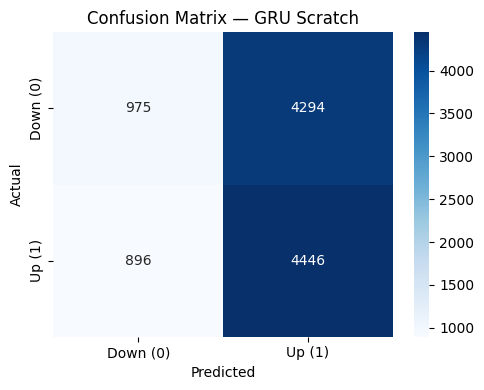

  ✔ Figure saved → /Users/mihiniboteju/cryptoflow/figures/cm_gru_scratch.png


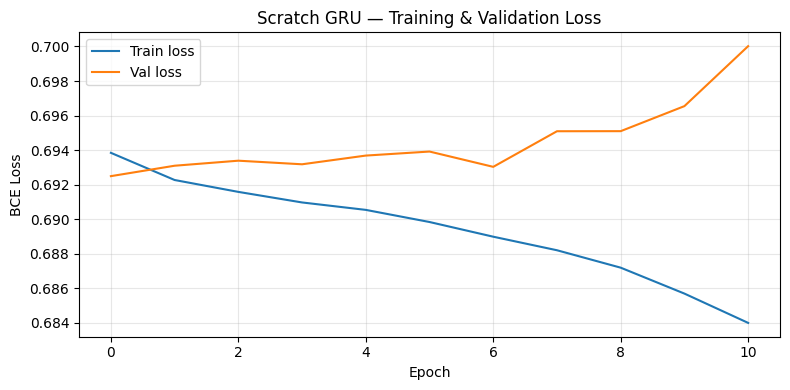

  ✔ Scratch model saved → /Users/mihiniboteju/cryptoflow/models/gru_scratch.pkl


In [ ]:
# ── Evaluate scratch GRU on test set ──────────────────────────────────────────
# ensure dill is available to pickle local/notebook-defined classes
%pip install dill --quiet
import dill

scratch_prob = gru_scratch.predict_proba(X_win_test)
scratch_pred = gru_scratch.predict(X_win_test)
scratch_metrics = compute_metrics('GRU Scratch', y_win_test, scratch_pred, scratch_prob)

print("=== Scratch GRU — Test Set ===")
for k, v in scratch_metrics.items():
    print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")

plot_confusion_matrix(
    y_win_test, scratch_pred,
    model_name='GRU Scratch',
    save_path=os.path.join(FIGURES_DIR, 'cm_gru_scratch.png')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_train_losses, label='Train loss')
ax.plot(scratch_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Scratch GRU — Training & Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'loss_gru_scratch.png'), dpi=120)
plt.show()

scratch_model_path = os.path.join(MODELS_DIR, 'gru_scratch.pkl')
with open(scratch_model_path, 'wb') as f:
    dill.dump(gru_scratch, f)
print(f"  ✔ Scratch model saved → {scratch_model_path}")

## Part 2 — PyTorch GRU

Uses `nn.GRU(batch_first=True)` with the same architecture, training loop, and early-stopping logic as the PyTorch LSTM in notebook 9. Because GRU has ~25% fewer parameters the training loop should converge faster per epoch.

In [ ]:
class GRUModel(nn.Module):
    """Single-layer GRU → Linear(64→1) → Sigmoid for binary classification."""

    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.gru    = nn.GRU(input_dim, hidden_dim,
                             num_layers=num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)            # (batch, seq_len, hidden_dim)
        h_last  = out[:, -1, :]         # last timestep: (batch, hidden_dim)
        logit   = self.linear(h_last)   # (batch, 1)
        return torch.sigmoid(logit).squeeze(1)


def train_pytorch_gru(model, X_tr, y_tr, X_val, y_val,
                      epochs, batch_size, patience, lr, device='cpu'):
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32, device=device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch_size, shuffle=True)

    best_val, best_state, wait = np.inf, None, 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        epoch_loss = 0.0

        for xb, yb in loader:
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * len(xb)

        epoch_loss /= len(X_tr)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:>3}/{epochs}  "
              f"train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}  "
              f"({elapsed:.1f}s)")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch} "
                      f"(best val_loss={best_val:.4f})")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses


torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

pt_model = GRUModel(input_dim=len(FEATURES), hidden_dim=HIDDEN, num_layers=N_LAYERS)
print("Training PyTorch GRU …")
pt_model, pt_train_losses, pt_val_losses = train_pytorch_gru(
    pt_model, X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE, lr=LR, device=DEVICE
)
print("Done.")

Device: cpu
Training PyTorch GRU …
  Epoch   1/50  train_loss=0.6923  val_loss=0.6935  (4.0s)
  Epoch   2/50  train_loss=0.6917  val_loss=0.6932  (3.9s)
  Epoch   3/50  train_loss=0.6916  val_loss=0.6929  (3.9s)
  Epoch   4/50  train_loss=0.6910  val_loss=0.6931  (3.7s)
  Epoch   5/50  train_loss=0.6907  val_loss=0.6940  (3.8s)
  Epoch   6/50  train_loss=0.6904  val_loss=0.6931  (3.9s)
  Epoch   7/50  train_loss=0.6900  val_loss=0.6929  (4.1s)
  Epoch   8/50  train_loss=0.6895  val_loss=0.6951  (3.6s)
  Epoch   9/50  train_loss=0.6890  val_loss=0.6928  (3.7s)
  Epoch  10/50  train_loss=0.6884  val_loss=0.6967  (4.0s)
  Epoch  11/50  train_loss=0.6876  val_loss=0.6938  (4.0s)
  Epoch  12/50  train_loss=0.6866  val_loss=0.6936  (3.8s)
  Epoch  13/50  train_loss=0.6854  val_loss=0.6938  (5.0s)
  Epoch  14/50  train_loss=0.6841  val_loss=0.6955  (3.9s)
  Epoch  15/50  train_loss=0.6823  val_loss=0.6941  (3.8s)
  Epoch  16/50  train_loss=0.6807  val_loss=0.6955  (3.7s)
  Epoch  17/50  train

=== PyTorch GRU — Test Set ===
  model       : GRU PyTorch
  accuracy    : 0.5159
  precision   : 0.5145
  sensitivity : 0.6795
  specificity : 0.3500
  tnr         : 0.3500
  f1          : 0.5856
  roc_auc     : 0.5207
  tp          : 3630.0000
  tn          : 1844.0000
  fp          : 3425.0000
  fn          : 1712.0000
  recall      : 0.6795


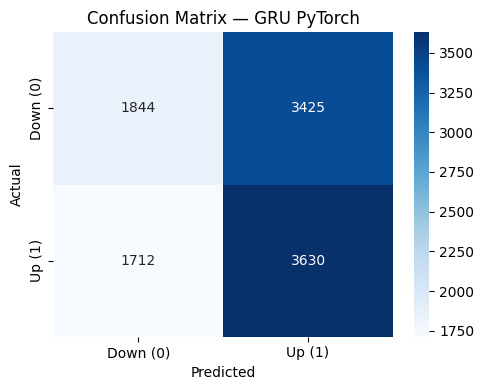

  ✔ Figure saved → /Users/mihiniboteju/cryptoflow/figures/cm_gru_pytorch.png


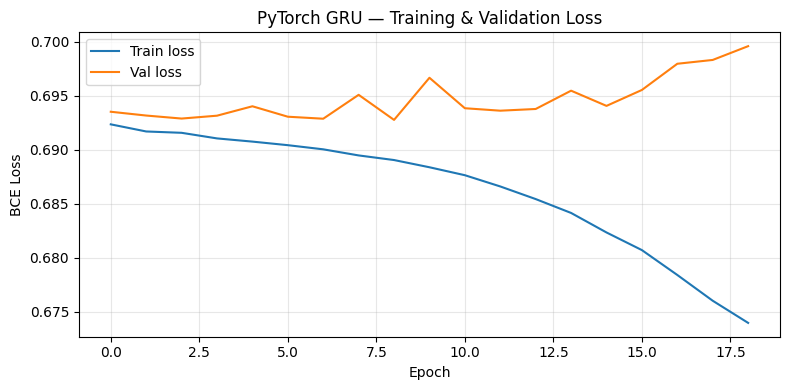

  ✔ PyTorch model saved → /Users/mihiniboteju/cryptoflow/models/gru_pytorch.pth


In [ ]:
# ── Evaluate PyTorch GRU on test set ──────────────────────────────────────────
pt_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_win_test, dtype=torch.float32, device=DEVICE)
    pt_prob   = pt_model(X_test_t).cpu().numpy()

pt_pred    = (pt_prob >= 0.5).astype(int)
pt_metrics = compute_metrics('GRU PyTorch', y_win_test, pt_pred, pt_prob)

print("=== PyTorch GRU — Test Set ===")
for k, v in pt_metrics.items():
    print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")

plot_confusion_matrix(
    y_win_test, pt_pred,
    model_name='GRU PyTorch',
    save_path=os.path.join(FIGURES_DIR, 'cm_gru_pytorch.png')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pt_train_losses, label='Train loss')
ax.plot(pt_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('PyTorch GRU — Training & Validation Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'loss_gru_pytorch.png'), dpi=120)
plt.show()

pt_model_path = os.path.join(MODELS_DIR, 'gru_pytorch.pkl')
torch.save(pt_model.state_dict(), pt_model_path)
print(f"  ✔ PyTorch model saved → {pt_model_path}")


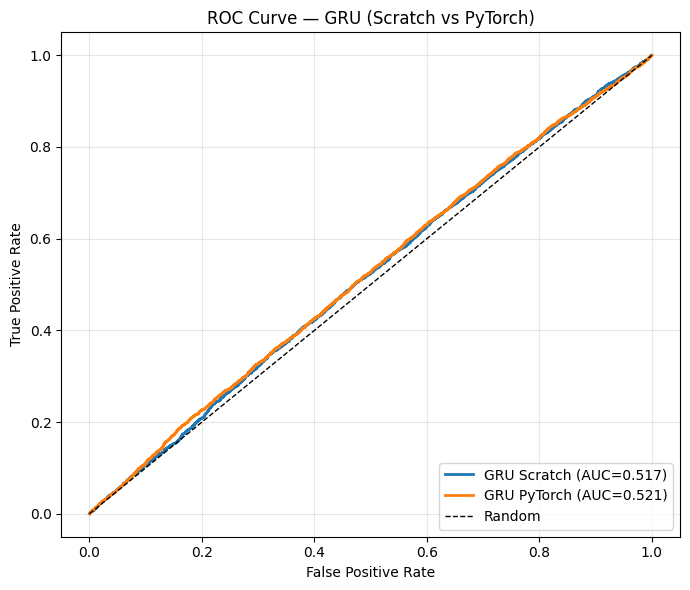

  ✔ ROC figure saved → /Users/mihiniboteju/cryptoflow/figures/roc_gru_comparison.png
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv
  ✔ Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

=== Full Classification Results ===
                                  model  accuracy  precision  sensitivity  specificity    tnr     f1  roc_auc        tp        tn        fp        fn  recall
                Majority Class Baseline    0.5034     0.5034       1.0000       0.0000 0.0000 0.6697   0.5000 5354.0000    0.0000 5281.0000    0.0000     NaN
          Logistic Regression (Scratch)    0.5236     0.5265       0.5334       0.5137 0.5137 0.5300   0.5388 2856.0000 2713.0000 2568.0000 2498.0000     NaN
          Logistic Regression (sklearn)    0.5247     0.5275       0.5347       0.5145 0.5145 0.5311   0.5386 2863.0000 2717.0000 2564.0000 2491.0000     NaN
                Decision Tree (Scratch)    0.5296     0.5327       0.5334 

In [ ]:
# ── ROC Curves — GRU Scratch vs PyTorch ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for label, probs in [('GRU Scratch', scratch_prob), ('GRU PyTorch', pt_prob)]:
    fpr, tpr, _ = roc_curve(y_win_test, probs)
    auc_val      = roc_auc_score(y_win_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — GRU (Scratch vs PyTorch)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_gru_comparison.png')
fig.savefig(roc_path, dpi=120)
plt.show()
print(f"  ✔ ROC figure saved → {roc_path}")

# ── Save results ───────────────────────────────────────────────────────────────
save_results(scratch_metrics)
save_results(pt_metrics)

# ── Full results table ─────────────────────────────────────────────────────────
results_df = pd.read_csv(RESULTS_CSV)
pd.set_option('display.float_format', '{:.4f}'.format)
print("\n=== Full Classification Results ===")
print(results_df.to_string(index=False))